# 利用預先訓練的模型來辨識圖像中的物體
    原始圖片>Tensor>model>output
## TorchVision function

In [93]:
#顯示可用模型
from torchvision import models
dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

## AlexNet
這是一個非常小型的神經網路,主要適合新手認識神經網路
輸入->過濾X5->圖片
其實就是標準的正向運行網路(dorward pass)網路
如果需要獲得所需要的結果需要修矮他的層參數才能緩步實驗獲得


In [94]:
# AlexNet 使用

## ResNet 
這是殘缺網路,執行下列程式碼後將會開始下載模型,其內部參數高達百萬參數

In [95]:
from torchvision import models
# ResNet 範例
resnet18 = models.resnet101(pretrained=True)
print(resnet18)

c:\Users\kevin_kai\Desktop\project\class-AI-Programming-Design\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\kevin_kai\Desktop\project\class-AI-Programming-Design\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# 最好運行的準備
這裡看到的每一列都是一個模組,我們可以像呼叫函式一樣呼叫resent 這個變數,輸入為圖片輸出為1000個ImageNET類別標籤的信心分數


In [96]:
from torchvision.transforms import transforms
from torch import mean
Process = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


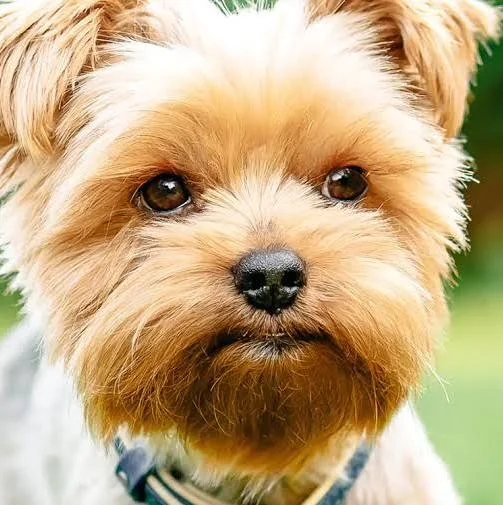

In [97]:
from PIL import Image
img = Image.open('./dog.png').convert('RGB')
img

In [98]:
import torch
from torchvision import models
resnet = models.resnet101(pretrained=True)
img_t = Process(img)
img_t.size()
batch_t = torch.unsqueeze(img_t, 0)
batch_t.shape()
resnet.eval()
out = resnet(batch_t)
_,index = torch.max(out, 1)
index[0]





TypeError: 'torch.Size' object is not callable

In [ ]:
with open('imagenet_classes.txt') as f:
    labels = [line.strip() for line in f.readlines()]
persentage = torch.nn.functional.softmax(out, dim=1)[0]
labels[index[0]],persentage[index[0]].item()